In [63]:
import os, zipfile, warnings
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.transform import array_bounds
from rasterio.features import rasterize

# -------- USER INPUTS --------
r_compound   = r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif"   # Compound (D)
r_slr_only   = r"D:\Phd Research\Final_Raster\Inundation_only_for_SLR.tif"          # SLR-only
r_surge_only = r"D:\Phd Research\Final_Raster\inundation for only storm surge 100 yr_v2_stat.tif"  # Surge-only
r_q_only     = r"D:\Phd Research\Final_Raster\100yr_Q_flood_only.tif"               # River-only

# Optional land boundary (zipped shapefile)
boundary_zip = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"

# Compute FAF only where compound depth >= THRESH (meters)
THRESH = 0.000010

# Output (ONLY ONE: UTM 14N)
OUT_DIR      = r"D:\Phd Research\Final_Raster"
OUT_TIF_32614= os.path.join(OUT_DIR, "FAF_EPSG32614_V2.tif")
CRS_UTM14N   = "EPSG:32614"

# Nodata & reprojection
NODATA_OUT        = -9999.0
RESAMPLING_METHOD = Resampling.bilinear  # for continuous rasters
# -----------------------------

def read_depth(path):
    """Read single-band raster as float32; convert NoData & negatives to NaN; return array + profile."""
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")
        nod = src.nodata
        if nod is not None:
            arr = np.where(arr == nod, np.nan, arr)
        arr = np.where(arr < 0, np.nan, arr)  # depths must be >=0
        prof = src.profile
    return arr, prof

def reproject_array_to(arr, src_prof, dst_prof, resampling=Resampling.bilinear):
    """Reproject array to target profile, honoring NaNs."""
    dst = np.full((dst_prof["height"], dst_prof["width"]), np.nan, dtype=np.float32)
    reproject(
        source=arr, destination=dst,
        src_transform=src_prof["transform"], src_crs=src_prof["crs"],
        dst_transform=dst_prof["transform"], dst_crs=dst_prof["crs"],
        resampling=resampling,
        src_nodata=np.nan, dst_nodata=np.nan
    )
    return dst

def rasterize_land_mask(zip_path, target_prof):
    """Rasterize land polygon(s) on target grid; return boolean mask or None."""
    if not (zip_path and os.path.exists(zip_path)):
        return None
    out_dir = os.path.splitext(zip_path)[0] + "_unzipped"
    if not os.path.isdir(out_dir) or not any(f.lower().endswith(".shp") for f in os.listdir(out_dir)):
        os.makedirs(out_dir, exist_ok=True)
        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall(out_dir)
    shp_files = [os.path.join(out_dir, f) for f in os.listdir(out_dir) if f.lower().endswith(".shp")]
    if not shp_files:
        return None
    gdf = gpd.read_file(shp_files[0])
    if gdf.crs is None:
        warnings.warn("Boundary shapefile has no CRS—skipping land mask.")
        return None
    gdf = gdf.to_crs(target_prof["crs"])
    land = rasterize(
        [(geom, 1) for geom in gdf.geometry],
        out_shape=(target_prof["height"], target_prof["width"]),
        transform=target_prof["transform"],
        fill=0, dtype="uint8"
    ).astype(bool)
    return land

def build_target_profile_like(ref_prof, dst_crs):
    """Create a target profile in dst_crs preserving approximate source pixel size."""
    src_h, src_w = ref_prof["height"], ref_prof["width"]
    bounds = array_bounds(src_h, src_w, ref_prof["transform"])
    px_w = abs(ref_prof["transform"].a)
    px_h = abs(ref_prof["transform"].e)
    dst_transform, dst_w, dst_h = calculate_default_transform(
        ref_prof["crs"], dst_crs, src_w, src_h, *bounds, resolution=(px_w, px_h)
    )
    return {
        "driver": "GTiff",
        "height": dst_h,
        "width":  dst_w,
        "count": 1,
        "dtype": "float32",
        "crs":   dst_crs,
        "transform": dst_transform
    }

def write_tiled_gtiff(path_out, arr, width, height, transform, crs, nodata=NODATA_OUT):
    """Write a SINGLE tiled GeoTIFF with safe 256x256 blocks (prevents StripOffsets & tile-size errors)."""
    meta = {
        "driver": "GTiff",
        "width":  width,
        "height": height,
        "count":  1,
        "dtype":  "float32",
        "crs":    crs,
        "transform": transform,
        "nodata": nodata,
        "compress": "LZW",
        "tiled": True,
        "blockxsize": 256,
        "blockysize": 256,
        "predictor": 2
    }
    out = arr.copy()
    nan_mask = ~np.isfinite(out)
    if np.any(nan_mask): out[nan_mask] = nodata
    with rasterio.open(path_out, "w", **meta) as dst:
        dst.write(out.astype("float32"), 1)

def main():
    os.makedirs(OUT_DIR, exist_ok=True)

    # --- Read inputs ---
    D,    profD      = read_depth(r_compound)
    SLR,  prof_slr   = read_depth(r_slr_only)
    SURG, prof_surge = read_depth(r_surge_only)
    Q,    prof_q     = read_depth(r_q_only)

    # --- Bring single-driver depths onto the COMPOUND grid ---
    SLR_on_D  = reproject_array_to(SLR,  prof_slr,   profD, resampling=RESAMPLING_METHOD)
    SURG_on_D = reproject_array_to(SURG, prof_surge, profD, resampling=RESAMPLING_METHOD)
    Q_on_D    = reproject_array_to(Q,    prof_q,     profD, resampling=RESAMPLING_METHOD)

    # --- Per-pixel Dmax, then FAF ---
    Dmax = np.nanmax(np.stack([SLR_on_D, SURG_on_D, Q_on_D], axis=0), axis=0)
    eps = 1e-6
    valid = np.isfinite(D) & np.isfinite(Dmax) & (D >= THRESH) & (Dmax > eps)

    FAF_native = np.full_like(D, np.nan, dtype=np.float32)
    FAF_native[valid] = (D[valid] - Dmax[valid]) / Dmax[valid]

    # --- Build a UTM14N target profile matching source resolution ---
    prof_32614 = build_target_profile_like(profD, CRS_UTM14N)

    # --- Reproject FAF_native to EPSG:32614 ---
    FAF_32614 = reproject_array_to(FAF_native, profD, prof_32614, resampling=Resampling.bilinear)

    # --- Optional land mask in the TARGET CRS (EPSG:32614) ---
    land_mask = rasterize_land_mask(boundary_zip, prof_32614)
    if land_mask is not None:
        FAF_32614[~land_mask] = np.nan  # keep only land pixels if boundary provided

    # --- Write ONLY the UTM14N file (tiled, safe block sizes) ---
    write_tiled_gtiff(
        OUT_TIF_32614,
        FAF_32614,
        width=prof_32614["width"],
        height=prof_32614["height"],
        transform=prof_32614["transform"],
        crs=prof_32614["crs"],
        nodata=NODATA_OUT
    )
    print(f"[OK] Wrote FAF (EPSG:32614): {OUT_TIF_32614}")

    # --- Quick stats ---
    m = np.isfinite(FAF_32614)
    if np.any(m):
        print(f"Evaluated pixels: {np.count_nonzero(m):,}")
        print(f"Amplified (FAF>0): {100*np.mean(FAF_32614[m] > 0):.1f}% | "
              f"Attenuated (FAF<0): {100*np.mean(FAF_32614[m] < 0):.1f}%")
        print(f"FAF stats — mean: {np.nanmean(FAF_32614):.3f} | "
              f"median: {np.nanmedian(FAF_32614):.3f} | "
              f"min: {np.nanmin(FAF_32614):.3f} | max: {np.nanmax(FAF_32614):.3f}")
    else:
        print("No valid FAF pixels — check THRESH, inputs, or land mask.")

if __name__ == "__main__":
    warnings.filterwarnings("ignore")
    main()


[OK] Wrote FAF (EPSG:32614): D:\Phd Research\Final_Raster\FAF_EPSG32614_V2.tif
Evaluated pixels: 347,595
Amplified (FAF>0): 53.7% | Attenuated (FAF<0): 44.7%
FAF stats — mean: -0.027 | median: 0.000 | min: -1.000 | max: 37.950


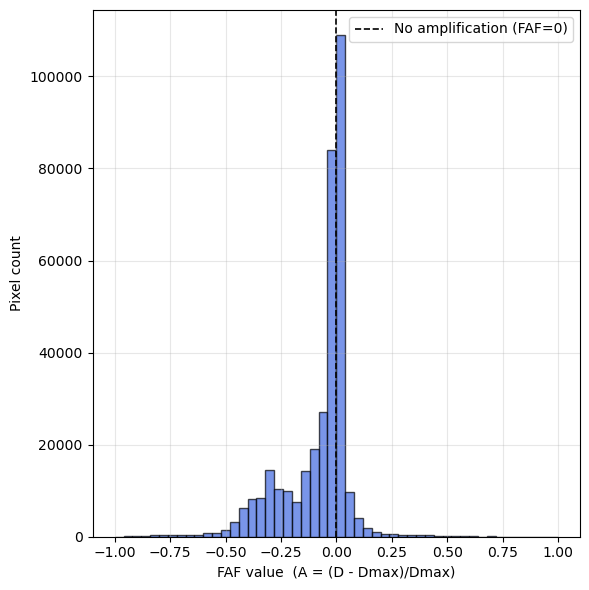

In [75]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# --- User input ---
r_faf = r"D:\Phd Research\Final_Raster\FAF_EPSG32614_V3.tif"  # your raster path
THRESHOLD = -9999  # or the nodata value used in your file

# --- Read raster ---
with rasterio.open(r_faf) as src:
    faf = src.read(1)
    nodata = src.nodata if src.nodata is not None else THRESHOLD

# --- Clean data ---
faf = faf.astype(float)
faf = faf[np.isfinite(faf)]                # remove NaNs
faf = faf[faf != nodata]                   # remove NoData
faf = faf[(faf >= -1) & (faf <= 1)]        # keep only valid FAF range

# --- Plot histogram ---
plt.figure(figsize=(6, 6))
plt.hist(faf, bins=50, color='royalblue', edgecolor='k', alpha=0.7)
plt.axvline(0, color='k', linestyle='--', linewidth=1.2, label='No amplification (FAF=0)')
# plt.title("Distribution of Flood Amplification Factor (FAF)")
plt.xlabel("FAF value  (A = (D - Dmax)/Dmax)")
plt.ylabel("Pixel count")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# # --- Optional stats ---
# print(f"Mean FAF: {np.mean(faf):.3f}")
# print(f"Median FAF: {np.median(faf):.3f}")
# print(f"Amplified pixels (%): {(np.sum(faf > 0) / len(faf)) * 100:.1f}")
# print(f"Attenuated pixels (%): {(np.sum(faf < 0) / len(faf)) * 100:.1f}")


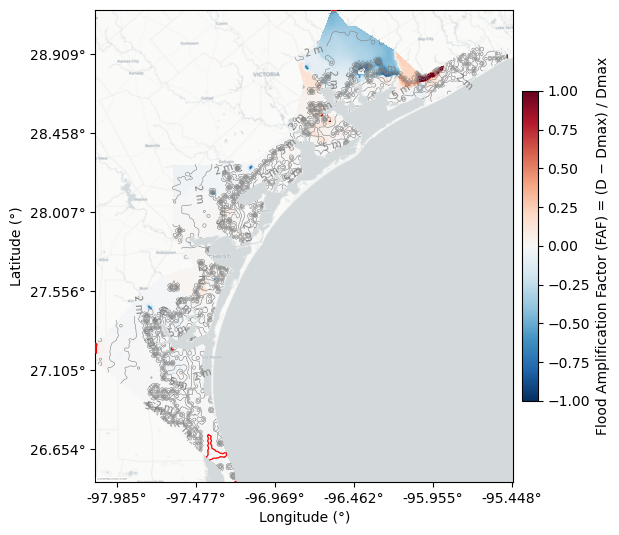

In [64]:
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.transform import array_bounds
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.ticker import FuncFormatter

# basemap + reprojection utilities
import contextily as ctx
from pyproj import Transformer

# ============== USER INPUTS ==============
FAF_PATH = r"D:\Phd Research\Final_Raster\FAF_EPSG32614_V2.tif"
DEM_PATH = r"D:\Phd Research\Final_Raster\land_part_area_DEM.tif"
OUT_PNG  = r"D:\Phd Research\Final_Raster\FAF_with_DEMcontours_basemap_latlon.png"

# FAF display
FAF_RANGE = (-1, 1)
FAF_ALPHA = 1.0

# Contours (visually refined, thin gray style)
LINE_COLOR   = "0.5"     # light gray (0=black, 1=white); "0.6" or "0.7" also works nicely
LINE_WIDTH   = 0.4       # thinner line
LINE_ZORD    = 7
DRAW_ZERO    = True
ZERO_COLOR   = "red"     # make 0 m contour stand out, or use "darkorange"
ZERO_LW      = 0.8       # slightly bolder but still thin
CLABEL_SIZE  = 7         # a bit smaller labels for neatness
CLABEL_EVERY = 3         # label fewer contours to avoid clutter

# Lat/Long graticule (optional fine lines; not the Matplotlib grid)
DRAW_GRATICULE   = False
DLON = 0.10
DLAT = 0.10
GRAT_COLOR = "0.4"
GRAT_LW    = 0.6
GRAT_ALPHA = 0.5
GRAT_ZORD  = 5

# Output
DPI = 300
# ========================================

def read_band(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")
        nd  = src.nodata
        if nd is not None:
            arr = np.where(arr == nd, np.nan, arr)
        prof = {"crs": src.crs, "transform": src.transform, "width": src.width, "height": src.height}
    return arr, prof

def coords_from_affine(transform, width, height):
    a, b, c, d, e, f = transform.a, transform.b, transform.c, transform.d, transform.e, transform.f
    cols = np.arange(width, dtype=np.float64) + 0.5
    rows = np.arange(height, dtype=np.float64) + 0.5
    C, R = np.meshgrid(cols, rows)  # (H,W)
    X = a * C + b * R + c
    Y = d * C + e * R + f
    return X, Y

# ---------- load data ----------
FAF, pf = read_band(FAF_PATH)
DEM, pd = read_band(DEM_PATH)

# Reproject DEM → FAF grid
DEM_on = np.full((pf["height"], pf["width"]), np.nan, dtype="float32")
reproject(
    source=DEM,
    destination=DEM_on,
    src_transform=pd["transform"], src_crs=pd["crs"],
    dst_transform=pf["transform"], dst_crs=pf["crs"],
    resampling=Resampling.bilinear,
    src_nodata=np.nan, dst_nodata=np.nan
)

# DEM stats & 1 m contour levels (UPDATED)
finite = DEM_on[np.isfinite(DEM_on)]
if finite.size == 0:
    raise RuntimeError("DEM has no finite values after reprojection; check inputs.")
dmin, dmax = float(np.nanmin(finite)), float(np.nanmax(finite))
# make neat integer bounds
lo = int(np.floor(dmin))
hi = int(np.ceil(dmax))
levels = list(np.arange(lo, hi + 1, 1))  # 1 m interval
add_zero = DRAW_ZERO and (lo <= 0 <= hi)

# Map extent for imshow
left, bottom, right, top = array_bounds(pf["height"], pf["width"], pf["transform"])

# Coordinate grids for contouring (in map/UTM coords)
X, Y = coords_from_affine(pf["transform"], pf["width"], pf["height"])

# ---------- plot ----------
fig, ax = plt.subplots(figsize=(6, 6))

# FAF background
norm = TwoSlopeNorm(vmin=FAF_RANGE[0], vcenter=0.0, vmax=FAF_RANGE[1])
cmap = plt.cm.RdBu_r
cmap.set_bad(alpha=0.0)
im = ax.imshow(
    FAF, origin="upper",
    extent=[left, right, bottom, top],
    cmap=cmap, norm=norm, alpha=FAF_ALPHA, zorder=1
)

# Basemap behind (axes are in EPSG:32614; contextily will handle reproject)
try:
    ctx.add_basemap(
        ax,
        crs=pf["crs"],
        source=ctx.providers.CartoDB.Positron,
        attribution_size=0,
        zorder=0
    )
except Exception as e:
    print(f"[warn] Basemap not added ({e}). Continuing without basemap.")

# DEM contours (1 m interval)
CS = ax.contour(
    X, Y, DEM_on,
    levels=levels,
    colors=LINE_COLOR,
    linewidths=LINE_WIDTH,
    zorder=LINE_ZORD
)

if len(CS.levels) > 0:
    label_lvls = CS.levels[::max(1, CLABEL_EVERY)]
    ax.clabel(CS, label_lvls, inline=True, fmt="%.0f m", fontsize=CLABEL_SIZE)

# Optional bold 0 m contour
if add_zero:
    ax.contour(
        X, Y, DEM_on,
        levels=[0.0],
        colors=ZERO_COLOR,
        linewidths=ZERO_LW,
        zorder=LINE_ZORD + 1
    )

# Lat/Long graticule (thin lines; separate from Matplotlib grid)
if DRAW_GRATICULE:
    to_ll = Transformer.from_crs(pf["crs"], "EPSG:4326", always_xy=True)
    to_utm = Transformer.from_crs("EPSG:4326", pf["crs"], always_xy=True)

    # derive lon/lat bounds from UTM extent
    xs = np.array([left, right])
    ys = np.array([bottom, top])
    XX, YY = np.meshgrid(xs, ys)
    lons, lats = to_ll.transform(XX, YY)
    lon_min, lon_max = float(np.nanmin(lons)), float(np.nanmax(lons))
    lat_min, lat_max = float(np.nanmin(lats)), float(np.nanmax(lats))

    lon_start = np.floor(lon_min / DLON) * DLON
    lon_end   = np.ceil(lon_max / DLON) * DLON
    lat_start = np.floor(lat_min / DLAT) * DLAT
    lat_end   = np.ceil(lat_max / DLAT) * DLAT

    # Meridians
    lats_line = np.linspace(lat_start, lat_end, 200)
    for lon in np.arange(lon_start, lon_end + 1e-9, DLON):
        lons_line = np.full_like(lats_line, lon)
        xg, yg = to_utm.transform(lons_line, lats_line)
        ax.plot(xg, yg, color=GRAT_COLOR, linewidth=GRAT_LW, alpha=GRAT_ALPHA, zorder=GRAT_ZORD)

    # Parallels
    lons_line = np.linspace(lon_start, lon_end, 200)
    for lat in np.arange(lat_start, lat_end + 1e-9, DLAT):
        lats_line = np.full_like(lons_line, lat)
        xg, yg = to_utm.transform(lons_line, lats_line)
        ax.plot(xg, yg, color=GRAT_COLOR, linewidth=GRAT_LW, alpha=GRAT_ALPHA, zorder=GRAT_ZORD)

# ---------- Axis in lat/lon (UPDATED) ----------
# Format tick labels by converting UTM tick locations → lon/lat
to_ll_ticks = Transformer.from_crs(pf["crs"], "EPSG:4326", always_xy=True)

def xtick_to_lon(x, pos):
    lon, lat = to_ll_ticks.transform(x, (ax.get_ylim()[0] + ax.get_ylim()[1]) / 2.0)
    return f"{lon:.3f}°"

def ytick_to_lat(y, pos):
    lon, lat = to_ll_ticks.transform((ax.get_xlim()[0] + ax.get_xlim()[1]) / 2.0, y)
    return f"{lat:.3f}°"

ax.xaxis.set_major_formatter(FuncFormatter(xtick_to_lon))
ax.yaxis.set_major_formatter(FuncFormatter(ytick_to_lat))
ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")

# Remove Matplotlib gridlines (UPDATED)
ax.grid(False)

# Colorbar & cosmetics
cb = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cb.set_label("Flood Amplification Factor (FAF) = (D − Dmax) / Dmax")

# ax.set_title("FAF with 1 m DEM Contours and Basemap (axes in lat/lon)")
ax.set_aspect("equal")

plt.tight_layout()
plt.savefig(OUT_PNG, dpi=DPI)
plt.show()
# print(f"[OK] Figure saved: {OUT_PNG}")


In [9]:
import rasterio
r = r"D:\Phd Research\Final_Raster\land_part_area_DEM.tif"
with rasterio.open(r) as src:
    print("CRS:", src.crs)
    print("Pixel size (m):", (src.transform.a, -src.transform.e))


CRS: EPSG:32614
Pixel size (m): (200.0, 200.0)


In [16]:
import rasterio
import numpy as np

dem_path = r"D:\Phd Research\Final_Raster\land_part_area_DEM.tif"

with rasterio.open(dem_path) as src:
    dem = src.read(1).astype(float)
    nodata = src.nodata
    if nodata is not None:
        dem = np.where(dem == nodata, np.nan, dem)

print("DEM CRS:", src.crs)
print("DEM shape:", dem.shape)
print("Min elevation (m):", np.nanmin(dem))
print("Max elevation (m):", np.nanmax(dem))
print("Mean elevation (m):", np.nanmean(dem))


DEM CRS: EPSG:32614
DEM shape: (1502, 1322)
Min elevation (m): -0.9971980452537537
Max elevation (m): 8.998937606811523
Mean elevation (m): 3.1875463180739


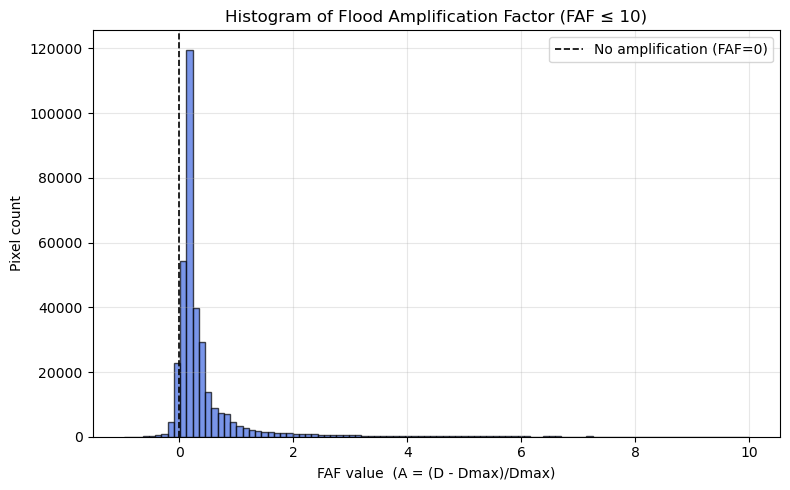

In [38]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# --- User input ---
r_faf = r"D:\Phd Research\Final_Raster\FAF_EPSG32614.tif"  # your raster path
THRESHOLD = -9999  # or nodata value if missing

# --- Read raster ---
with rasterio.open(r_faf) as src:
    faf = src.read(1)
    nodata = src.nodata if src.nodata is not None else THRESHOLD

# --- Clean data ---
faf = faf.astype(float)
faf = faf[np.isfinite(faf)]      # remove NaN
faf = faf[faf != nodata]         # remove NoData
faf = faf[faf <= 10]             # ignore extreme positive values (>10)

# --- Plot histogram ---
plt.figure(figsize=(8, 5))
plt.hist(faf, bins=100, color='royalblue', edgecolor='k', alpha=0.7)
plt.axvline(0, color='k', linestyle='--', linewidth=1.2, label='No amplification (FAF=0)')
plt.title("Histogram of Flood Amplification Factor (FAF ≤ 10)")
plt.xlabel("FAF value  (A = (D - Dmax)/Dmax)")
plt.ylabel("Pixel count")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


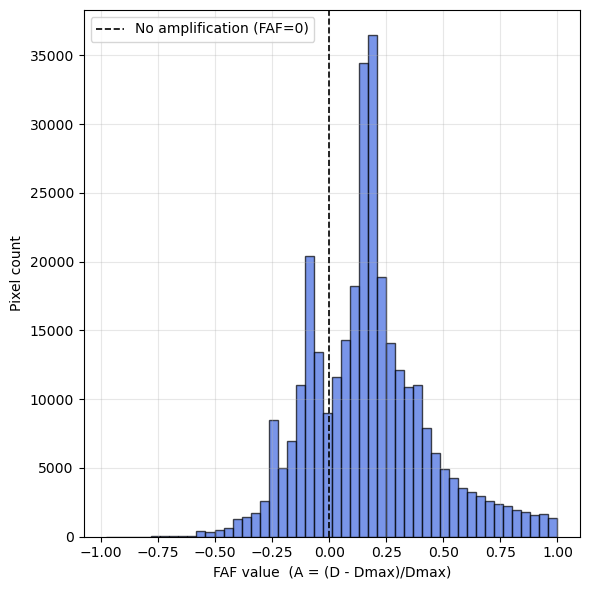

In [49]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# --- User input ---
r_faf = r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat_Amplification_perPixelSUM.tif"  # your raster path
THRESHOLD = -9999  # or the nodata value used in your file

# --- Read raster ---
with rasterio.open(r_faf) as src:
    faf = src.read(1)
    nodata = src.nodata if src.nodata is not None else THRESHOLD

# --- Clean data ---
faf = faf.astype(float)
faf = faf[np.isfinite(faf)]                # remove NaNs
faf = faf[faf != nodata]                   # remove NoData
faf = faf[(faf >= -1) & (faf <= 1)]        # keep only valid FAF range

# --- Plot histogram ---
plt.figure(figsize=(6, 6))
plt.hist(faf, bins=50, color='royalblue', edgecolor='k', alpha=0.7)
plt.axvline(0, color='k', linestyle='--', linewidth=1.2, label='No amplification (FAF=0)')
# plt.title("Distribution of Flood Amplification Factor (FAF)")
plt.xlabel("FAF value  (A = (D - Dmax)/Dmax)")
plt.ylabel("Pixel count")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

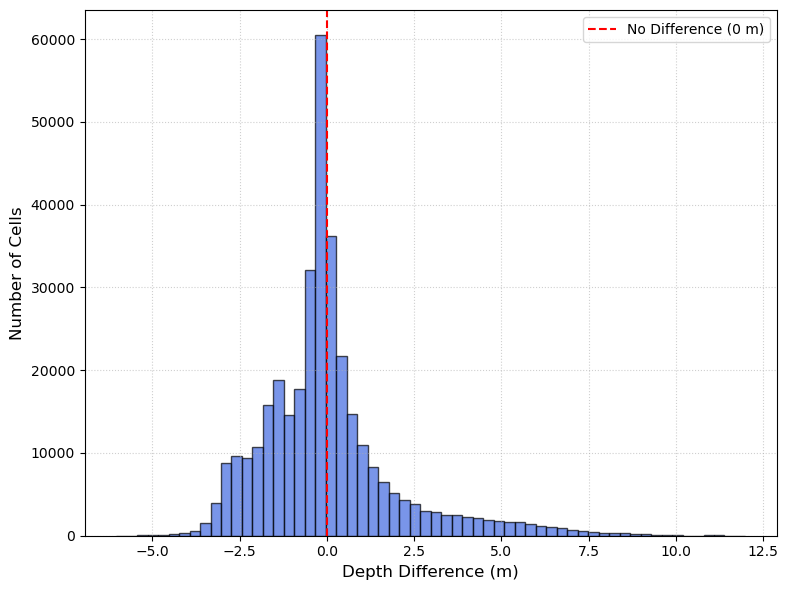

In [50]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# -------- USER INPUT --------
r_diff = r"D:\Phd Research\Final_Raster\diff_process_bath_100yr.tif"

# -------- READ RASTER --------
with rasterio.open(r_diff) as src:
    diff = src.read(1).astype(float)
    nodata = src.nodata if src.nodata is not None else -9999.0

# -------- CLEAN DATA --------
mask = np.isfinite(diff) & (diff != nodata)
diff_valid = diff[mask]

# Optional: remove extreme outliers if needed (e.g., ±12 m)
diff_valid = diff_valid[(diff_valid >= -12) & (diff_valid <= 12)]

# print(f"Total valid cells: {diff_valid.size:,}")

# -------- HISTOGRAM PLOT --------
plt.figure(figsize=(8,6))
plt.hist(diff_valid, bins=60, color='royalblue', edgecolor='k', alpha=0.7)

# Add a vertical line at zero (no difference)
plt.axvline(0, color='red', linestyle='--', linewidth=1.5, label='No Difference (0 m)')

# Labels and title
# plt.title("Frequency Distribution of Depth Difference\n(Process-based – Bathtub, 100-year)", fontsize=13)
plt.xlabel("Depth Difference (m)", fontsize=12)
plt.ylabel("Number of Cells", fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


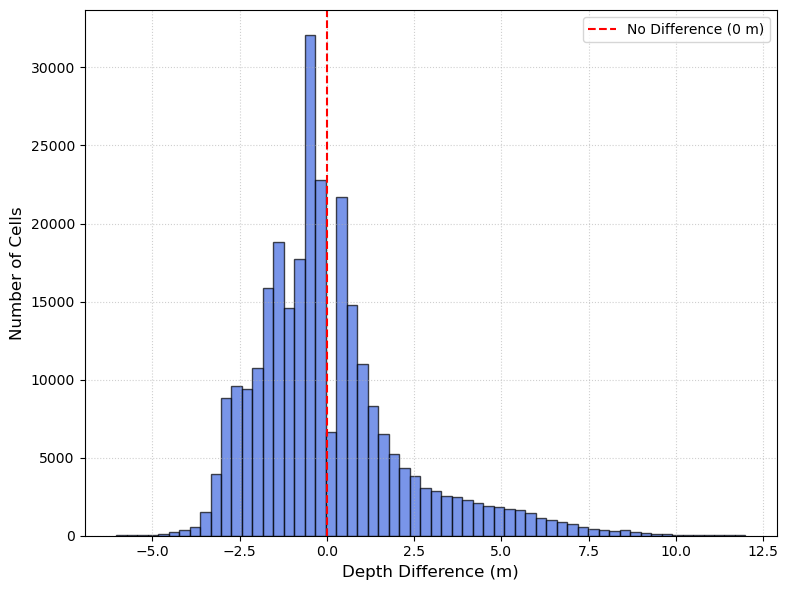

In [52]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# -------- USER INPUT --------
r_diff = r"D:\Phd Research\Final_Raster\diff_process_bath_100yr.tif"

# -------- READ RASTER --------
with rasterio.open(r_diff) as src:
    diff = src.read(1).astype(float)
    nodata = src.nodata if src.nodata is not None else -9999.0

# -------- CLEAN DATA --------
mask = np.isfinite(diff) & (diff != nodata)
diff_valid = diff[mask]

# Keep only meaningful differences (clip extremes and discard near-zero)
diff_valid = diff_valid[(diff_valid >= -12) & (diff_valid <= 12)]   # limit valid range
diff_valid = diff_valid[(diff_valid <= -0.2) | (diff_valid >= 0.2)] # exclude -0.2 m < x < 0.2 m

# print(f"Total valid cells after filtering: {diff_valid.size:,}")

# -------- HISTOGRAM PLOT --------
plt.figure(figsize=(8,6))
plt.hist(diff_valid, bins=60, color='royalblue', edgecolor='k', alpha=0.7)

# Add a vertical reference line at zero
plt.axvline(0, color='red', linestyle='--', linewidth=1.5, label='No Difference (0 m)')

# Labels and styling
plt.xlabel("Depth Difference (m)", fontsize=12)
plt.ylabel("Number of Cells", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


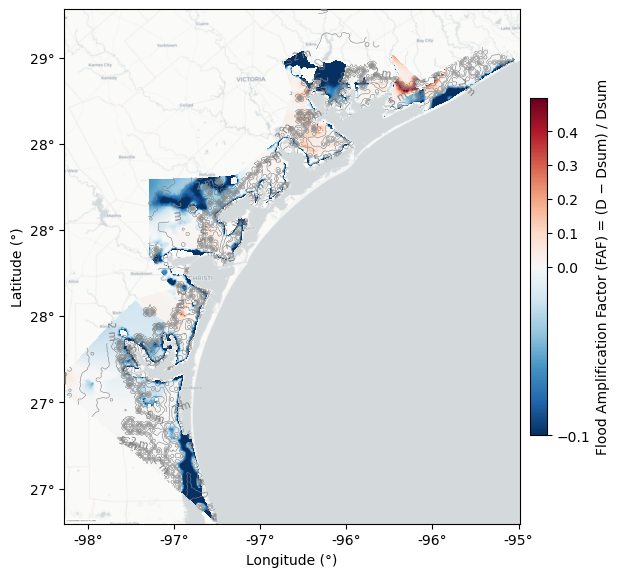

In [74]:
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.transform import array_bounds
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.ticker import FuncFormatter

# basemap + reprojection utilities
import contextily as ctx
from pyproj import Transformer

# ============== USER INPUTS ==============
FAF_PATH = r"D:\Phd Research\Final_Raster\FAF_EPSG32614_V3.tif"
DEM_PATH = r"D:\Phd Research\Final_Raster\land_part_area_DEM.tif"
OUT_PNG  = r"D:\Phd Research\Final_Raster\FAF_with_DEMcontours_basemap_latlon.png"

# FAF display
FAF_RANGE = (-0.1, 0.5)
FAF_ALPHA = 1.0

# Contours (visually refined, thin gray style)
LINE_COLOR   = "0.5"     # light gray (0=black, 1=white)
LINE_WIDTH   = 0.4
LINE_ZORD    = 7
DRAW_ZERO    = True
ZERO_COLOR   = "red"
ZERO_LW      = 0.8
CLABEL_SIZE  = 7
CLABEL_EVERY = 3

# Lat/Long graticule (optional)
DRAW_GRATICULE   = False
DLON = 0.10
DLAT = 0.10
GRAT_COLOR = "0.4"
GRAT_LW    = 0.6
GRAT_ALPHA = 0.5
GRAT_ZORD  = 5

# Output
DPI = 300
# ========================================

def read_band(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")
        nd  = src.nodata
        if nd is not None:
            arr = np.where(arr == nd, np.nan, arr)
        prof = {"crs": src.crs, "transform": src.transform, "width": src.width, "height": src.height}
    return arr, prof

def coords_from_affine(transform, width, height):
    a, b, c, d, e, f = transform.a, transform.b, transform.c, transform.d, transform.e, transform.f
    cols = np.arange(width, dtype=np.float64) + 0.5
    rows = np.arange(height, dtype=np.float64) + 0.5
    C, R = np.meshgrid(cols, rows)  # (H,W)
    X = a * C + b * R + c
    Y = d * C + e * R + f
    return X, Y

# ---------- load data ----------
FAF, pf = read_band(FAF_PATH)
DEM, pd = read_band(DEM_PATH)

# --- Filter FAF values to only show [-0.25, 0.75] ---
# Values < -0.25 or > 0.75 will be transparent (NaN)
FAF = np.where((FAF < -0.25) | (FAF > 0.75), np.nan, FAF)

# Reproject DEM → FAF grid
DEM_on = np.full((pf["height"], pf["width"]), np.nan, dtype="float32")
reproject(
    source=DEM,
    destination=DEM_on,
    src_transform=pd["transform"], src_crs=pd["crs"],
    dst_transform=pf["transform"], dst_crs=pf["crs"],
    resampling=Resampling.bilinear,
    src_nodata=np.nan, dst_nodata=np.nan
)

# DEM stats & 1 m contour levels
finite = DEM_on[np.isfinite(DEM_on)]
if finite.size == 0:
    raise RuntimeError("DEM has no finite values after reprojection; check inputs.")
dmin, dmax = float(np.nanmin(finite)), float(np.nanmax(finite))
lo = int(np.floor(dmin))
hi = int(np.ceil(dmax))
levels = list(np.arange(lo, hi + 1, 1))  # 1 m interval
add_zero = DRAW_ZERO and (lo <= 0 <= hi)

# Map extent for imshow
left, bottom, right, top = array_bounds(pf["height"], pf["width"], pf["transform"])

# Coordinate grids for contouring (in UTM coords)
X, Y = coords_from_affine(pf["transform"], pf["width"], pf["height"])

# ---------- plot ----------
fig, ax = plt.subplots(figsize=(6, 6))

# FAF background
norm = TwoSlopeNorm(vmin=FAF_RANGE[0], vcenter=0.0, vmax=FAF_RANGE[1])
cmap = plt.cm.RdBu_r
cmap.set_bad(alpha=0.0)  # NaNs transparent
im = ax.imshow(
    FAF, origin="upper",
    extent=[left, right, bottom, top],
    cmap=cmap, norm=norm, alpha=FAF_ALPHA, zorder=1
)

# Basemap behind (axes are in EPSG:32614; contextily will handle reproject)
try:
    ctx.add_basemap(
        ax,
        crs=pf["crs"],
        source=ctx.providers.CartoDB.Positron,
        attribution_size=0,
        zorder=0
    )
except Exception as e:
    print(f"[warn] Basemap not added ({e}). Continuing without basemap.")

# DEM contours (1 m interval)
CS = ax.contour(
    X, Y, DEM_on,
    levels=levels,
    colors=LINE_COLOR,
    linewidths=LINE_WIDTH,
    zorder=LINE_ZORD
)

if len(CS.levels) > 0:
    label_lvls = CS.levels[::max(1, CLABEL_EVERY)]
    ax.clabel(CS, label_lvls, inline=True, fmt="%.0f m", fontsize=CLABEL_SIZE)

# # Optional bold 0 m contour
# if add_zero:
#     ax.contour(
#         X, Y, DEM_on,
#         levels=[0.0],
#         colors=ZERO_COLOR,
#         linewidths=ZERO_LW,
#         zorder=LINE_ZORD + 1
#     )

# ---------- Axis in lat/lon ----------
to_ll_ticks = Transformer.from_crs(pf["crs"], "EPSG:4326", always_xy=True)

def xtick_to_lon(x, pos):
    lon, lat = to_ll_ticks.transform(x, (ax.get_ylim()[0] + ax.get_ylim()[1]) / 2.0)
    return f"{lon:.0f}°"

def ytick_to_lat(y, pos):
    lon, lat = to_ll_ticks.transform((ax.get_xlim()[0] + ax.get_xlim()[1]) / 2.0, y)
    return f"{lat:.0f}°"

ax.xaxis.set_major_formatter(FuncFormatter(xtick_to_lon))
ax.yaxis.set_major_formatter(FuncFormatter(ytick_to_lat))
ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
ax.grid(False)

# Colorbar & cosmetics
cb = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cb.set_label("Flood Amplification Factor (FAF) = (D − Dsum) / Dsum")

ax.set_aspect("equal")
plt.tight_layout()
plt.savefig(OUT_PNG, dpi=DPI)
plt.show()


In [72]:
import os, zipfile, warnings
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.transform import array_bounds
from rasterio.features import rasterize

# ---------------------- USER INPUTS ----------------------
r_compound   = r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif"   # Compound (D)
r_slr_only   = r"D:\Phd Research\Final_Raster\Inundation_only_for_SLR.tif"          # SLR-only
r_surge_only = r"D:\Phd Research\Final_Raster\inundation for only storm surge 100 yr_v2_stat.tif"  # Surge-only
r_q_only     = r"D:\Phd Research\Final_Raster\100yr_Q_flood_only.tif"               # River-only

# Optional land boundary (zipped shapefile)
boundary_zip = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"

# Compute FAF only where compound depth >= THRESH (meters)
THRESH = 0.000010

# Output (ONLY ONE: UTM 14N)
OUT_DIR       = r"D:\Phd Research\Final_Raster"
OUT_TIF_32614 = os.path.join(OUT_DIR, "FAF_EPSG32614_V3.tif")
CRS_UTM14N    = "EPSG:32614"

# Nodata & reprojection
NODATA_OUT        = -9999.0
RESAMPLING_METHOD = Resampling.bilinear  # for continuous rasters
# --------------------------------------------------------


def read_depth(path):
    """Read single-band raster as float32; convert NoData & negatives to NaN; return array + profile."""
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")
        nod = src.nodata
        if nod is not None:
            arr = np.where(arr == nod, np.nan, arr)
        arr = np.where(arr < 0, np.nan, arr)  # depths must be >= 0
        prof = src.profile
    return arr, prof


def reproject_array_to(arr, src_prof, dst_prof, resampling=Resampling.bilinear):
    """Reproject array to target profile, honoring NaNs."""
    dst = np.full((dst_prof["height"], dst_prof["width"]), np.nan, dtype=np.float32)
    reproject(
        source=arr,
        destination=dst,
        src_transform=src_prof["transform"],
        src_crs=src_prof["crs"],
        dst_transform=dst_prof["transform"],
        dst_crs=dst_prof["crs"],
        resampling=resampling,
        src_nodata=np.nan,
        dst_nodata=np.nan
    )
    return dst


def rasterize_land_mask(zip_path, target_prof):
    """Rasterize land polygon(s) on target grid; return boolean mask or None."""
    if not (zip_path and os.path.exists(zip_path)):
        return None

    out_dir = os.path.splitext(zip_path)[0] + "_unzipped"
    if not os.path.isdir(out_dir) or not any(f.lower().endswith(".shp") for f in os.listdir(out_dir)):
        os.makedirs(out_dir, exist_ok=True)
        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall(out_dir)

    shp_files = [os.path.join(out_dir, f) for f in os.listdir(out_dir) if f.lower().endswith(".shp")]
    if not shp_files:
        return None

    gdf = gpd.read_file(shp_files[0])
    if gdf.crs is None:
        warnings.warn("Boundary shapefile has no CRS—skipping land mask.")
        return None

    gdf = gdf.to_crs(target_prof["crs"])
    land = rasterize(
        [(geom, 1) for geom in gdf.geometry],
        out_shape=(target_prof["height"], target_prof["width"]),
        transform=target_prof["transform"],
        fill=0,
        dtype="uint8"
    ).astype(bool)
    return land


def build_target_profile_like(ref_prof, dst_crs):
    """Create a target profile in dst_crs preserving approximate source pixel size."""
    src_h, src_w = ref_prof["height"], ref_prof["width"]
    bounds = array_bounds(src_h, src_w, ref_prof["transform"])
    px_w = abs(ref_prof["transform"].a)
    px_h = abs(ref_prof["transform"].e)
    dst_transform, dst_w, dst_h = calculate_default_transform(
        ref_prof["crs"], dst_crs, src_w, src_h, *bounds, resolution=(px_w, px_h)
    )
    return {
        "driver": "GTiff",
        "height": dst_h,
        "width":  dst_w,
        "count": 1,
        "dtype": "float32",
        "crs":   dst_crs,
        "transform": dst_transform
    }


def write_tiled_gtiff(path_out, arr, width, height, transform, crs, nodata=NODATA_OUT):
    """Write a SINGLE tiled GeoTIFF with safe 256x256 blocks (prevents StripOffsets & tile-size errors)."""
    meta = {
        "driver": "GTiff",
        "width":  width,
        "height": height,
        "count":  1,
        "dtype":  "float32",
        "crs":    crs,
        "transform": transform,
        "nodata": nodata,
        "compress": "LZW",
        "tiled": True,
        "blockxsize": 256,
        "blockysize": 256,
        "predictor": 2
    }
    out = arr.copy()
    nan_mask = ~np.isfinite(out)
    if np.any(nan_mask):
        out[nan_mask] = nodata
    with rasterio.open(path_out, "w", **meta) as dst:
        dst.write(out.astype("float32"), 1)


def main():
    os.makedirs(OUT_DIR, exist_ok=True)

    # --- Read inputs ---
    D,    profD      = read_depth(r_compound)
    SLR,  prof_slr   = read_depth(r_slr_only)
    SURG, prof_surge = read_depth(r_surge_only)
    Q,    prof_q     = read_depth(r_q_only)

    # --- Bring single-driver depths onto the COMPOUND grid ---
    SLR_on_D  = reproject_array_to(SLR,  prof_slr,   profD, resampling=RESAMPLING_METHOD)
    SURG_on_D = reproject_array_to(SURG, prof_surge, profD, resampling=RESAMPLING_METHOD)
    Q_on_D    = reproject_array_to(Q,    prof_q,     profD, resampling=RESAMPLING_METHOD)

    # --- Per-pixel Dsum (SLR + Surge + River), then FAF ---
    Dsum = np.nansum(np.stack([SLR_on_D, SURG_on_D, Q_on_D], axis=0), axis=0)
    eps = 1e-6
    valid = np.isfinite(D) & np.isfinite(Dsum) & (D >= THRESH) & (Dsum > eps)

    FAF_native = np.full_like(D, np.nan, dtype=np.float32)
    FAF_native[valid] = (D[valid] - Dsum[valid]) / Dsum[valid]

    # --- Build a UTM14N target profile matching source resolution ---
    prof_32614 = build_target_profile_like(profD, CRS_UTM14N)

    # --- Reproject FAF_native to EPSG:32614 ---
    FAF_32614 = reproject_array_to(FAF_native, profD, prof_32614, resampling=Resampling.bilinear)

    # --- Optional land mask in the TARGET CRS (EPSG:32614) ---
    land_mask = rasterize_land_mask(boundary_zip, prof_32614)
    if land_mask is not None:
        FAF_32614[~land_mask] = np.nan  # keep only land pixels if boundary provided

    # --- Write ONLY the UTM14N file (tiled, safe block sizes) ---
    write_tiled_gtiff(
        OUT_TIF_32614,
        FAF_32614,
        width=prof_32614["width"],
        height=prof_32614["height"],
        transform=prof_32614["transform"],
        crs=prof_32614["crs"],
        nodata=NODATA_OUT
    )
    print(f"[OK] Wrote FAF (EPSG:32614): {OUT_TIF_32614}")

    # --- Quick stats ---
    m = np.isfinite(FAF_32614)
    if np.any(m):
        print(f"Evaluated pixels: {np.count_nonzero(m):,}")
        print(f"Amplified (FAF>0): {100*np.mean(FAF_32614[m] > 0):.1f}% | "
              f"Attenuated (FAF<0): {100*np.mean(FAF_32614[m] < 0):.1f}%")
        print(f"FAF stats — mean: {np.nanmean(FAF_32614):.3f} | "
              f"median: {np.nanmedian(FAF_32614):.3f} | "
              f"min: {np.nanmin(FAF_32614):.3f} | max: {np.nanmax(FAF_32614):.3f}")
    else:
        print("No valid FAF pixels — check THRESH, inputs, or land mask.")


if __name__ == "__main__":
    warnings.filterwarnings("ignore")
    main()


[OK] Wrote FAF (EPSG:32614): D:\Phd Research\Final_Raster\FAF_EPSG32614_V3.tif
Evaluated pixels: 347,595
Amplified (FAF>0): 34.8% | Attenuated (FAF<0): 65.1%
FAF stats — mean: -0.076 | median: -0.016 | min: -1.000 | max: 29.809
